<a href="https://colab.research.google.com/github/anirvinv/NeuralText/blob/master/NeuralNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [30]:
import numpy as np

class Layer_Dense:
  def __init__(self, n_neurons, n_features):
    self.weights = np.random.random((n_neurons, n_features)) * 0.001
    self.bias = np.random.random((n_neurons, 1)) * 0.001

  def forward(self, X):
    self.output = np.dot(self.weights, X) + self.bias
    return self.output


class Activation:
  def __init__(self, func):
    if func == 'sigm':
      self.func = lambda z: 1/(1 + np.exp(-z))
    if func == 'reLU':
      self.func = lambda z: np.maximum(0, z)
  def forward(self, X):
    self.output = self.func(X)
    return self.output


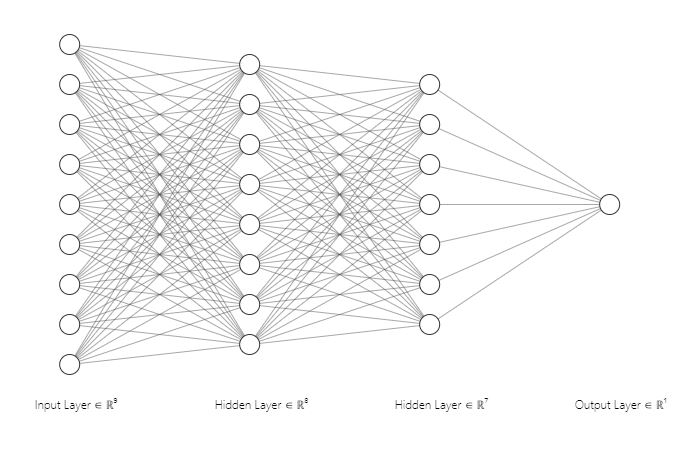

In [31]:
def d_relu(nums1):
  nums = nums1.copy()
  nums[nums<=0] = 0
  nums[nums>0] = 1
  return nums


X = np.linspace(0, 5, 50).reshape(50, 1).T

y = X**2

def reset_network():
  global l1, l2, l3, l4, act1, act2, act3  
  l1 = Layer_Dense(9,1)
  l2 = Layer_Dense(8, 9)
  l3 = Layer_Dense(7, 8)
  l4 = Layer_Dense(1, 7)
  act1 = Activation('reLU')
  act2 = Activation('reLU')
  act3 = Activation('reLU')

**Gradients**

Forward Prop

W1 * X + b1 = z1

reLU(z1) = a1



---



W2 * a1 + b2 = z2

reLU(z2) = a2



---



W3 * a2 + b1 = z3

reLU(z3) = a3



---



W4 * a3 + b1 = z4



 

Loss Function: MSE: $$J = {1/M}\sum_1^M (z^{(4)} - y)^2$$

In [32]:
# dz4 = 2*(z4-y)

# dW4 = np.dot((dz4), a3.T)
# db4 = np.sum((dz4), axis=1, keepdims=True)

# #dW3 = dz4 * dz4_da3 * da3_dz3 * dz3_dW3
# dW3 = np.dot((np.dot(l4.weights.T, dz4) * d_relu(z3)), a2.T)
# db3 = np.sum((np.dot(l4.weights.T, dz4) * d_relu(z3)), axis=1, keepdims=True)

# #dW2 = dz4 * dz4_da3 * da3_dz3 * dz3_da2 * da2_dz2 * dz2_dW2
# dW2 = np.dot(np.dot(l3.weights.T,(np.dot(l4.weights.T, dz4) * d_relu(z3))) * d_relu(z2), a1.T) 
# db2 = np.sum(np.dot(l3.weights.T,(np.dot(l4.weights.T, dz4) * d_relu(z3))) * d_relu(z2), axis=1, keepdims=True)

# #dW2 = dz4 * dz4_da3 * da3_dz3 * dz3_da2 * da2_dz2 * dz2_da1 * da1_dz1 * dz1_dW1 
# dW1 = np.dot(np.dot(l2.weights.T,np.dot(l3.weights.T, np.dot(l4.weights.T, dz4) * d_relu(z3)) * d_relu(z2)) * d_relu(z1), X.T)
# db1 = np.sum(np.dot(l2.weights.T,np.dot(l3.weights.T, np.dot(l4.weights.T, dz4) * d_relu(z3)) * d_relu(z2)) * d_relu(z1), axis=1, keepdims=True)

In [33]:
def LSE(y1, y2):
  return np.sum((y1 - y2)**2)
def MSE(y1, y2):
  return (1/y.size)*np.sum((y1 - y2)**2)

Training


In [34]:
reset_network()

X = np.linspace(0, 1, 50).reshape(50, 1).T

y = (X)**2

epochs = 1500
lr = 0.01

m = X.size

for i in range(epochs):
  
  z1 = l1.forward(X)
  a1 = act1.forward(z1)

  z2 = l2.forward(a1)
  a2 = act2.forward(z2)

  z3 = l3.forward(a2)
  a3 = act3.forward(z3)

  z4 = l4.forward(a3)
  
  dz4 = 2*(z4-y)

  dW4 = (1/m)*np.dot((dz4), a3.T)
  db4 = (1/m)*np.sum((dz4), axis=1, keepdims=True)

  #dW3 = dJ_dz4 * dz4_da3 * da3_dz3 * dz3_dW3
  dW3 = (1/m)*np.dot((np.dot(l4.weights.T, dz4) * d_relu(z3)), a2.T)
  db3 = (1/m)*np.sum((np.dot(l4.weights.T, dz4) * d_relu(z3)), axis=1, keepdims=True)

  #dW2 = dJ_dz4 * dz4_da3 * da3_dz3 * dz3_da2 * da2_dz2 * dz2_dW2
  dW2 = (1/m)*np.dot(np.dot(l3.weights.T,np.dot(l4.weights.T, dz4) * d_relu(z3)) * d_relu(z2), a1.T) 
  db2 = (1/m)*np.sum(np.dot(l3.weights.T,(np.dot(l4.weights.T, dz4) * d_relu(z3))) * d_relu(z2), axis=1, keepdims=True)

  #dW1 = dJ_dz4 * dz4_da3 * da3_dz3 * dz3_da2 * da2_dz2 * dz2_da1 * da1_dz1 * dz1_dW1 
  dW1 = (1/m)*np.dot(np.dot(l2.weights.T,np.dot(l3.weights.T, np.dot(l4.weights.T, dz4) * d_relu(z3)) * d_relu(z2)) * d_relu(z1), X.T)
  db1 = (1/m)*np.sum(np.dot(l2.weights.T,np.dot(l3.weights.T, np.dot(l4.weights.T, dz4) * d_relu(z3)) * d_relu(z2)) * d_relu(z1), axis=1, keepdims=True)

  l1.weights -= dW1 * lr
  l2.weights -= dW2 * lr
  l3.weights -= dW3 * lr
  l4.weights -= dW4 * lr
  
  l1.bias -= db1 * lr
  l2.bias -= db2 * lr
  l3.bias -= db3 * lr
  l4.bias -= db4 * lr

  if i % 55 == 0:
    print(i,"   ", LSE(z4, y),MSE(z4, y))
    # print(i, "   ", l4.bias)
    # print(i, '\n',z4)
    # print(i, np.sum(dW3))
    


0     10.291152759273091 0.20582305518546182
55     5.249936461575492 0.10499872923150985
110     4.703675371800806 0.09407350743601611
165     4.6444831938036035 0.09288966387607207
220     4.638069207864343 0.09276138415728687
275     4.637374197061539 0.09274748394123078
330     4.637298886642852 0.09274597773285705
385     4.637290726109307 0.09274581452218614
440     4.637289841845108 0.09274579683690216
495     4.637289746027454 0.09274579492054909
550     4.637289735644783 0.09274579471289567
605     4.63728973451973 0.09274579469039461
660     4.637289734397821 0.09274579468795642
715     4.63728973438461 0.0927457946876922
770     4.637289734383177 0.09274579468766354
825     4.63728973438302 0.09274579468766041
880     4.637289734383002 0.09274579468766005
935     4.637289734383 0.09274579468765999
990     4.637289734382998 0.09274579468765996
1045     4.637289734382996 0.09274579468765992
1100     4.637289734382996 0.09274579468765992
1155     4.6372897343829935 0.0927457946

In [35]:
np.average(y),z4

(0.336734693877551,
 array([[0.33673469, 0.33673469, 0.33673469, 0.33673469, 0.33673469,
         0.33673469, 0.33673469, 0.33673469, 0.33673469, 0.33673469,
         0.33673469, 0.33673469, 0.33673469, 0.33673469, 0.33673469,
         0.33673469, 0.33673469, 0.33673469, 0.33673469, 0.33673469,
         0.33673469, 0.33673469, 0.33673469, 0.33673469, 0.33673469,
         0.33673469, 0.33673469, 0.33673469, 0.33673469, 0.33673469,
         0.33673469, 0.33673469, 0.33673469, 0.33673469, 0.33673469,
         0.33673469, 0.33673469, 0.33673469, 0.33673469, 0.33673469,
         0.33673469, 0.33673469, 0.33673469, 0.33673469, 0.33673469,
         0.33673469, 0.33673469, 0.33673469, 0.33673469, 0.33673469]]))

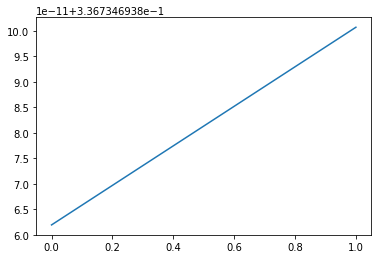

In [36]:
import matplotlib.pyplot as plt

plt.plot(X.T, z4.T)

In [65]:
def create_params():
  global W1, b1, b2, W2

  W1 = np.random.random((10,1))
  b1 = np.random.random((10,1))

  W2 = np.random.random((1, 10))
  b2 = np.random.random((1, 1)) 

In [140]:
def sigmoid(x):
  return 1/(1 + np.exp(-x))
def d_sigmoid(x):
  return sigmoid(x) * (1 - sigmoid(x))

create_params()

X1 = np.linspace(0, 3.14159265, 30).reshape(1, 30)
y1 = np.sin(X1)

z1 = W1 @ X1 + b1
a1 = sigmoid(z1)

z2 = W2 @ a1 + b2
a2 = sigmoid(z2) 

In [144]:
rate = 0.01
create_params()
iter = 10000
for i in range(iter):
  z1 = W1 @ X1 + b1
  a1 = sigmoid(z1)

  z2 = W2 @ a1 + b2
  a2 = sigmoid(z2) 

  da2 = 2 * (a2 - y1)

  #dW2 = dJ_da2 * da2_dz2 * dz2_dW2 
  dJ_dW2 =  np.dot(da2 * d_sigmoid(z2), a1.T)
  dJ_db2 =  np.sum(da2 * d_sigmoid(z2), axis=1, keepdims=True)

  #dW2 = dJ_da2 * da2_dz2 * dz2_da1 * da1_dz1 * dz1*dW1
  dJ_dW1 = np.dot(np.dot(W2.T, da2 * d_sigmoid(z2)) * d_sigmoid(z1), X1.T)
  dJ_db1 = np.sum(np.dot(W2.T, da2 * d_sigmoid(z2)) * d_sigmoid(z1), axis=1, keepdims=True)

  W1 -= dJ_dW1 * rate
  W2 -= dJ_dW2 * rate
  b1 -= dJ_db1 * rate
  b2 -= dJ_db2 * rate

  if i % 500 == 0:
    print("Total Error: ",LSE(y1, a2))


Total Error:  7.142003265942991
Total Error:  2.985477873039227
Total Error:  2.6400043074682844
Total Error:  2.140313583113263
Total Error:  1.6110092449941735
Total Error:  1.1373740974716327
Total Error:  0.7730392763731143
Total Error:  0.5261862303488278
Total Error:  0.3690862920431335
Total Error:  0.27024276937134434
Total Error:  0.20723952553182273
Total Error:  0.16614482613833845
Total Error:  0.13859433417074515
Total Error:  0.11956846627683712
Total Error:  0.10601857946794073
Total Error:  0.09606129472778244
Total Error:  0.08851159149625887
Total Error:  0.08261091497753842
Total Error:  0.07786637617073353
Total Error:  0.073953504284424


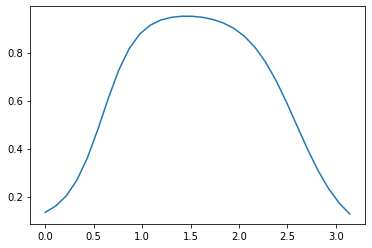

In [145]:
plt.plot(X1.T, a2.T)

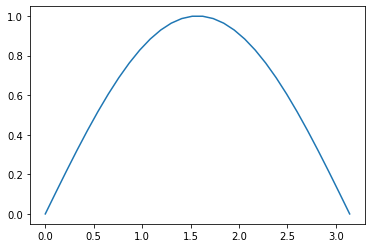

In [143]:
plt.plot(X1.T, y1.T)